<a href="https://colab.research.google.com/github/Bosmithan/Code/blob/main/TeaLeaf_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Programming_Assignment_02"))

source_dir = "/content/drive/MyDrive/Programming_Assignment_02/Data_A2"

import os
print(os.listdir(source_dir))

['Data_A2', 'Programming_Assignment_02_S20854.ipynb']
['brown blight', 'algal leaf', 'white spot']


In [ ]:
import os
import shutil
import random

train_dir = "/content/train"
val_dir = "/content/validation"

classes = os.listdir(source_dir)

for cls in classes:
    class_path = os.path.join(source_dir, cls)

    if not os.path.isdir(class_path):
        continue

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    images = os.listdir(class_path)
    images = [img for img in images if img.lower().endswith(".jpg")]

    random.shuffle(images)

    split = int(0.8 * len(images))

    for img in images[:split]:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(train_dir, cls, img))

    for img in images[split:]:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(val_dir, cls, img))

print("Dataset split completed!")

Dataset split completed!


In [ ]:
import os
print(os.listdir())


['.config', 'validation', 'train', 'drive', 'sample_data']


In [ ]:
pip uninstall -y jax jaxlib

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    'validation',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 363 images belonging to 3 classes.
Found 183 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze base model

model_vgg = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_vgg = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 303s 13s/step - accuracy: 0.3747 - loss: 1.1093 - val_accuracy: 0.5191 - val_loss: 1.0056
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 348s 15s/step - accuracy: 0.5207 - loss: 1.0131 - val_accuracy: 0.5574 - val_loss: 0.9497
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 304s 13s/step - accuracy: 0.5592 - loss: 0.9443 - val_accuracy: 0.6448 - val_loss: 0.9126
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 302s 13s/step - accuracy: 0.6006 - loss: 0.9253 - val_accuracy: 0.6448 - val_loss: 0.8684
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 300s 13s/step - accuracy: 0.5895 - loss: 0.8847 - val_accuracy: 0.6776 - val_loss: 0.8364
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 343s 15s/step - accuracy: 0.6474 - loss: 0.8451 - val_accuracy: 0.6667 - val_loss: 0.8132
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 300s 13s/step - accuracy: 0.6722 - loss: 0.7886 - val_accuracy: 0.6557 - val_loss: 0.7796
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 300s 13s/step - accuracy: 0.6364 - loss: 0.8009 - val_accuracy: 0.

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model2 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model2.trainable = False

model_resnet = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.3691 - loss: 1.1816 - val_accuracy: 0.4754 - val_loss: 1.0824
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.3416 - loss: 1.1505 - val_accuracy: 0.5246 - val_loss: 1.0929
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 105s 5s/step - accuracy: 0.3664 - loss: 1.0962 - val_accuracy: 0.3607 - val_loss: 1.0676
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.3719 - loss: 1.1028 - val_accuracy: 0.3825 - val_loss: 1.0715
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.3802 - loss: 1.0890 - val_accuracy: 0.4481 - val_loss: 1.0644
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.4325 - loss: 1.0620 - val_accuracy: 0.3880 - val_loss: 1.0472
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.3829 - loss: 1.0739 - val_accuracy: 0.4863 - val_loss: 1.0768
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.4215 - loss: 1.0714 - val_accuracy: 0.3825 - val_l

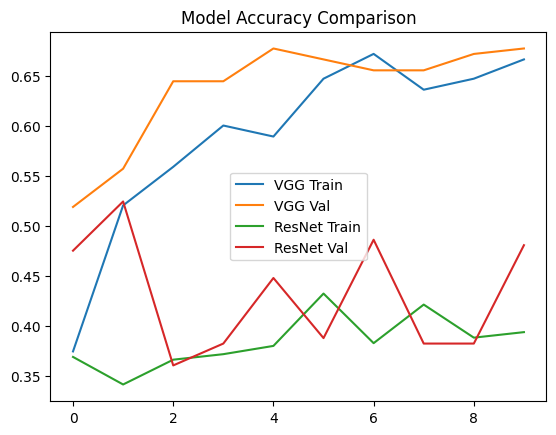

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['accuracy'], label='VGG Train')
plt.plot(history_vgg.history['val_accuracy'], label='VGG Val')

plt.plot(history_resnet.history['accuracy'], label='ResNet Train')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet Val')

plt.legend()
plt.title("Model Accuracy Comparison")
plt.show()

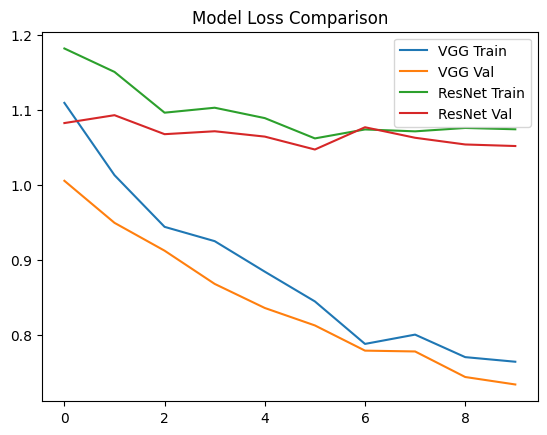

In [ ]:
plt.plot(history_vgg.history['loss'], label='VGG Train')
plt.plot(history_vgg.history['val_loss'], label='VGG Val')

plt.plot(history_resnet.history['loss'], label='ResNet Train')
plt.plot(history_resnet.history['val_loss'], label='ResNet Val')

plt.legend()
plt.title("Model Loss Comparison")
plt.show()